In [75]:
# CELL 1: Import libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("=" * 50)
print("PART 1: LOADING AND EXPLORING DATA")
print("=" * 50)

PART 1: LOADING AND EXPLORING DATA


In [76]:
# CELL 2: Load transaction data
print("\n📂 Loading train_transaction.csv...")
transactions = pd.read_csv('/Users/snehareddy/fraud-detection-gnn/train_transaction.csv')

print(f"\n✅ Loaded {len(transactions):,} transactions")
print(f"   Columns: {len(transactions.columns)}")


📂 Loading train_transaction.csv...

✅ Loaded 590,540 transactions
   Columns: 394


In [77]:
# CELL 3: Load identity data
print("\n📂 Loading train_identity.csv...")
identity = pd.read_csv('train_identity.csv')

print(f"✅ Loaded {len(identity):,} identity records")
print(f"   Columns: {len(identity.columns)}")


📂 Loading train_identity.csv...
✅ Loaded 144,233 identity records
   Columns: 41


In [78]:
# CELL 4: Check fraud rate
fraud_count = transactions['isFraud'].sum()
fraud_rate = fraud_count / len(transactions) * 100

print("\n" + "=" * 50)
print("DATA SUMMARY")
print("=" * 50)
print(f"Total transactions: {len(transactions):,}")
print(f"Fraud cases: {fraud_count:,}")
print(f"Fraud rate: {fraud_rate:.2f}%")
print(f"Normal transactions: {len(transactions) - fraud_count:,}")


DATA SUMMARY
Total transactions: 590,540
Fraud cases: 20,663
Fraud rate: 3.50%
Normal transactions: 569,877


In [79]:
# CELL 5: Show first 5 rows
print("\n" + "=" * 50)
print("FIRST 5 TRANSACTIONS")
print("=" * 50)
print(transactions[['TransactionID', 'isFraud', 'TransactionAmt', 'ProductCD']].head())


FIRST 5 TRANSACTIONS
   TransactionID  isFraud  TransactionAmt ProductCD
0        2987000        0            68.5         W
1        2987001        0            29.0         W
2        2987002        0            59.0         W
3        2987003        0            50.0         W
4        2987004        0            50.0         H


In [80]:
# CELL 6: Check missing values
print("\n" + "=" * 50)
print("MISSING VALUES (Top 5 columns)")
print("=" * 50)
missing = transactions.isnull().sum().sort_values(ascending=False)
print(missing.head(5))


MISSING VALUES (Top 5 columns)
dist2    552913
D7       551623
D13      528588
D14      528353
D12      525823
dtype: int64


In [81]:
# CELL 7: Summary
print("\n" + "=" * 50)
print("✅ PART 1 COMPLETE!")
print("=" * 50)
print("\n📝 What we learned:")
print(f"   - We have {len(transactions):,} transactions")
print(f"   - Only {fraud_rate:.2f}% are fraud (very imbalanced!)")
print(f"   - Many columns have missing values")



✅ PART 1 COMPLETE!

📝 What we learned:
   - We have 590,540 transactions
   - Only 3.50% are fraud (very imbalanced!)
   - Many columns have missing values


In [82]:
# CELL 8: Merge transaction and identity data
print("\n" + "=" * 50)
print("PART 2: MERGING DATA & PREPARING FEATURES")
print("=" * 50)

print("\n🔗 Merging transactions with identity data...")

# Merge on TransactionID (like SQL JOIN)
data = transactions.merge(identity, on='TransactionID', how='left')

print(f"✅ Merged data: {len(data):,} rows, {len(data.columns)} columns")

# Check fraud rate in merged data
fraud_count = data['isFraud'].sum()
fraud_rate = fraud_count / len(data) * 100
print(f"   Fraud rate: {fraud_rate:.2f}%")


PART 2: MERGING DATA & PREPARING FEATURES

🔗 Merging transactions with identity data...
✅ Merged data: 590,540 rows, 434 columns
   Fraud rate: 3.50%


In [83]:
# CELL 9: Select features for the model
print("\n📋 Selecting important features...")

# These are the most important features from the IEEE-CIS dataset
features_to_use = [
    'TransactionAmt',        # Transaction amount
    'ProductCD',             # Product code
    'card1', 'card2', 'card3', 'card4',  # Card information
    'addr1', 'addr2',        # Address information
    'dist1',                 # Distance
    'P_emaildomain',         # Payer email
    'R_emaildomain',         # Recipient email
    'DeviceType',            # Device type
    'DeviceInfo',            # Device info
]

# Keep only features that exist in the data
available_features = [f for f in features_to_use if f in data.columns]
print(f"   Using {len(available_features)} features")
print(f"   Features: {available_features}")


📋 Selecting important features...
   Using 13 features
   Features: ['TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'addr1', 'addr2', 'dist1', 'P_emaildomain', 'R_emaildomain', 'DeviceType', 'DeviceInfo']


In [84]:
# Add missing-value indicator flags BEFORE filling with 0
# Why: filling numeric NaNs with 0 makes "missing" indistinguishable from "genuinely zero"
# (e.g. dist1 = 0 is a real recorded value, not missing data). This preserves that signal
# as a separate feature instead of throwing it away.
print("\n🚩 Creating missing-value indicator flags...")

numeric_features = [f for f in available_features if data[f].dtype in ['int64', 'float64']]
added_flags = []
for col in numeric_features:
    if data[col].isnull().sum() > 0:
        flag_col = f'{col}_was_missing'
        data[flag_col] = data[col].isnull().astype(int)
        available_features.append(flag_col)
        added_flags.append(flag_col)

print(f"   ✅ Added {len(added_flags)} missing-value flags: {added_flags}")


🚩 Creating missing-value indicator flags...
   ✅ Added 5 missing-value flags: ['card2_was_missing', 'card3_was_missing', 'addr1_was_missing', 'addr2_was_missing', 'dist1_was_missing']


In [85]:
# CELL 10: Handle missing values
print("\n🛠️ Handling missing values...")

# Check missing values before
missing_before = data[available_features].isnull().sum().sum()
print(f"   Missing values before: {missing_before:,}")

# Fill missing values with 0 (simple but effective)
data[available_features] = data[available_features].fillna(0)

# Fill missing values with 'unknown' for text columns
for col in available_features:
    if data[col].dtype == 'object':
        data[col] = data[col].fillna('unknown')

# Check missing values after
missing_after = data[available_features].isnull().sum().sum()
print(f"   Missing values after: {missing_after} ✅")


🛠️ Handling missing values...
   Missing values before: 1,965,067
   Missing values after: 0 ✅


In [86]:
# CELL 11: Convert text to numbers
from sklearn.preprocessing import LabelEncoder

print("\n🔢 Converting text to numbers...")

label_encoders = {}
for col in available_features:
    if data[col].dtype == 'object':  # If it's text
        le = LabelEncoder()
        data[col] = data[col].astype(str)
        data[col] = le.fit_transform(data[col])
        label_encoders[col] = le
        print(f"   ✅ Encoded: {col}")

print("   All features are now numeric!")


🔢 Converting text to numbers...
   ✅ Encoded: card4
   ✅ Encoded: P_emaildomain
   ✅ Encoded: R_emaildomain
   ✅ Encoded: DeviceType
   ✅ Encoded: DeviceInfo
   All features are now numeric!


In [87]:
# CELL 12: Normalize features (scale between 0 and 1)
print("\n📏 Normalizing features...")
from sklearn.preprocessing import StandardScaler

# In CELL 12, replace the loop with:
scaler = StandardScaler()
# Fit on training data only, then transform all data to avoid data leakage
# You'd need to separate train/test before scaling for a more rigorous approach.
# For simplicity here, we fit on all data (a common first step).
cols_to_scale = [f for f in available_features if data[f].dtype in ['int64', 'float64']]
data[cols_to_scale] = scaler.fit_transform(data[cols_to_scale])

print("   All features normalized to range [0, 1]")


📏 Normalizing features...
   All features normalized to range [0, 1]


In [88]:
# CELL 13: Check final prepared data
print("\n" + "=" * 50)
print("✅ DATA PREPARATION COMPLETE!")
print("=" * 50)

print(f"\n📊 Final data shape: {data.shape}")
print(f"   Features: {len(available_features)}")
print(f"   Fraud cases: {data['isFraud'].sum():,}")
print(f"   Fraud rate: {data['isFraud'].mean()*100:.2f}%")

# Show sample of prepared features
print("\n📋 Sample of prepared data:")
print(data[available_features + ['isFraud']].head())


✅ DATA PREPARATION COMPLETE!

📊 Final data shape: (590540, 439)
   Features: 18
   Fraud cases: 20,663
   Fraud rate: 3.50%

📋 Sample of prepared data:
   TransactionAmt ProductCD     card1     card2     card3     card4     addr1  \
0       -0.278167         W  0.821695 -2.194286 -0.202222 -2.607805  0.427260   
1       -0.443327         W -1.457558  0.288389 -0.202222 -0.982065  0.502728   
2       -0.317889         W -1.068263  0.816879 -0.202222  0.643675  0.540462   
3       -0.355521         W  1.679858  1.290062 -0.202222 -0.982065  1.642300   
4       -0.355521         H -1.102133  0.964364 -0.202222 -0.982065  1.219677   

      addr2     dist1  P_emaildomain  R_emaildomain  DeviceType  DeviceInfo  \
0  0.359582 -0.118444      -1.113624      -0.424112   -0.519255   -0.473565   
1  0.359582 -0.196550      -0.175683      -0.424112   -0.519255   -0.473565   
2  0.359582  0.983253       0.872603      -0.424112   -0.519255   -0.473565   
3  0.359582 -0.196550       1.865717      -0

In [89]:
# CELL 14: Save prepared data (optional - for faster loading later)
print("\n💾 Saving prepared data...")

# Save the prepared data
data[available_features + ['isFraud']].to_csv('prepared_data.csv', index=False)
print("✅ Saved to 'prepared_data.csv'")

print("\n📝 Part 2 Complete!")
print("   - Data merged")
print("   - Missing values handled")
print("   - Text converted to numbers")
print("   - Features normalized")



💾 Saving prepared data...
✅ Saved to 'prepared_data.csv'

📝 Part 2 Complete!
   - Data merged
   - Missing values handled
   - Text converted to numbers
   - Features normalized


In [90]:
# CELL 15: Install required libraries (run this once)
import subprocess
import sys

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Check if torch is installed
try:
    import torch
    print("✅ PyTorch already installed")
except:
    print("📦 Installing PyTorch...")
    install_package("torch")

# Install PyTorch Geometric
try:
    import torch_geometric
    print("✅ PyTorch Geometric already installed")
except:
    print("📦 Installing PyTorch Geometric...")
    install_package("torch_geometric")
    
print("\n✅ All libraries ready!")

✅ PyTorch already installed
✅ PyTorch Geometric already installed

✅ All libraries ready!


In [91]:
# CELL 16: Import libraries for graph building
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [92]:
# CELL 17: Load the prepared data
print("📂 Loading prepared data...")

# Load from the file we saved in Part 2
data = pd.read_csv('prepared_data.csv')

print(f"✅ Loaded {len(data):,} transactions")
print(f"   Features: {len(data.columns) - 1}")  # -1 for the 'isFraud' column

# Separate features and labels
feature_cols = [col for col in data.columns if col != 'isFraud']
X = data[feature_cols].values
y = data['isFraud'].values

print(f"   Feature shape: {X.shape}")
print(f"   Fraud cases: {sum(y):,}")

📂 Loading prepared data...
✅ Loaded 590,540 transactions
   Features: 18
   Feature shape: (590540, 18)
   Fraud cases: 20,663


In [93]:
# DEBUG: Find which column has 'W' value
print("🔍 Finding columns with text values...")

for col in feature_cols:
    if data[col].dtype == 'object':
        unique_vals = data[col].unique()
        print(f"\n{col}:")
        print(f"   Type: {data[col].dtype}")
        print(f"   Unique values: {unique_vals[:5]}")
        if 'W' in unique_vals:
            print(f"   ⚠️ Found 'W' in {col}!")

🔍 Finding columns with text values...


In [94]:
# CELL 17.5: Fix data types - Convert EVERYTHING to numbers
print("\n🛠️ Fixing data types...")

# Check which columns are still text
text_cols = []
for col in feature_cols:
    if data[col].dtype == 'object':
        text_cols.append(col)

if text_cols:
    print(f"   Found text columns: {text_cols}")
    print("   Converting text to numbers...")
    
    from sklearn.preprocessing import LabelEncoder
    for col in text_cols:
        le = LabelEncoder()
        # Convert to string first to handle any type
        data[col] = data[col].astype(str)
        # Fill 'nan' strings with 'unknown'
        data[col] = data[col].replace('nan', 'unknown')
        # Encode
        data[col] = le.fit_transform(data[col])
        print(f"   ✅ Encoded: {col}")
    
    # Update X with fixed data
    X = data[feature_cols].values
    print(f"   ✅ All features now numeric!")
else:
    print("   ✅ All features already numeric!")

# Force convert everything to numeric, replace any errors with 0
print("\n🔄 Converting to numeric (forcing)...")
X = pd.DataFrame(X)
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)

X = X.values

# Check data types
print(f"\n📊 Data types:")
print(f"   X dtype: {X.dtype}")
print(f"   X shape: {X.shape}")
print(f"   Sample values: {X[0][:5]}")

# Make sure everything is float
X = X.astype(np.float32)
print(f"\n✅ Fixed! X is now {X.dtype}")


🛠️ Fixing data types...
   ✅ All features already numeric!

🔄 Converting to numeric (forcing)...

📊 Data types:
   X dtype: float64
   X shape: (590540, 18)
   Sample values: [-0.27816747  0.          0.82169536 -2.19428575 -0.20222243]

✅ Fixed! X is now float32


In [95]:
# CELL 18: Create node features
print("\n🔢 Creating node features...")

# Convert to PyTorch tensor
x = torch.tensor(X, dtype=torch.float)

print(f"✅ Node features created: {x.shape}")
print(f"   Each transaction is now a node with {x.shape[1]} features")


🔢 Creating node features...
✅ Node features created: torch.Size([590540, 18])
   Each transaction is now a node with 18 features


In [96]:
# Create edges - connect transactions that share patterns
# CHANGES FROM ORIGINAL:
#  1. Large shared-card/device/email groups are SAMPLED instead of skipped entirely.
#     (Originally, any card1 used by 1000+ transactions was dropped completely -- but
#      heavily-shared cards/devices are often exactly the fraud-relevant signal, so
#      excluding them was likely throwing away the graph's most useful structure.)
#  2. The silent random-edge fallback has been removed. If real edges can't be built,
#     this now raises a clear error instead of quietly injecting meaningless noise.
print("\n🔗 Creating edges (connections between transactions)...")

original = pd.read_csv('prepared_data.csv')

import random
random.seed(42)

MAX_EDGES_PER_GROUP = 200  # cap per shared-value group so large groups still contribute

def build_edges_for_column(df, col, max_edges_per_group=MAX_EDGES_PER_GROUP):
    edges = []
    groups = df.groupby(col).size()
    for val, count in groups.items():
        if count <= 1:
            continue
        indices = df[df[col] == val].index.tolist()
        if count <= 50:
            pairs = [(indices[i], indices[j]) for i in range(len(indices)) for j in range(i+1, len(indices))]
        else:
            pairs = []
            for _ in range(max_edges_per_group):
                a, b = random.sample(indices, 2)
                pairs.append((a, b))
        edges.extend(pairs)
    return edges

edges = []

print("   Connecting transactions with same card...")
card_edges = build_edges_for_column(original, 'card1')
edges.extend(card_edges)
print(f"   ✅ Created {len(card_edges):,} edges from same card")

if 'DeviceInfo' in original.columns:
    print("   Connecting transactions with same device...")
    device_edges = build_edges_for_column(original, 'DeviceInfo')
    edges.extend(device_edges)
    print(f"   ✅ Created {len(device_edges):,} edges from same device")

if 'P_emaildomain' in original.columns:
    print("   Connecting transactions with same email domain...")
    email_edges = build_edges_for_column(original, 'P_emaildomain')
    edges.extend(email_edges)
    print(f"   ✅ Created {len(email_edges):,} edges from same email")

print(f"\n📊 Total edges created: {len(edges):,}")

assert len(edges) > 0, (
    "No edges were created from shared card/device/email. "
    "Fix the grouping logic above rather than falling back to random edges."
)


🔗 Creating edges (connections between transactions)...
   Connecting transactions with same card...
   ✅ Created 1,158,831 edges from same card
   Connecting transactions with same device...
   ✅ Created 139,983 edges from same device
   Connecting transactions with same email domain...
   ✅ Created 14,370 edges from same email

📊 Total edges created: 1,313,184


In [97]:
# CELL 20: Convert edges to PyTorch tensor
print("\n🔄 Converting edges to tensor...")

if len(edges) > 0:
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    print(f"✅ Edge tensor shape: {edge_index.shape}")
    print(f"   {edge_index.shape[1]:,} connections between transactions")
else:
    print("⚠️ No edges created! Let's create some basic connections...")
    # Fallback: connect random transactions
    import random
    random.seed(42)
    edges = []
    for i in range(min(10000, len(X))):
        for j in range(i+1, min(i+5, len(X))):
            if random.random() < 0.1:  # 10% chance of connection
                edges.append([i, j])
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    print(f"✅ Created fallback edges: {edge_index.shape[1]:,}")


🔄 Converting edges to tensor...
✅ Edge tensor shape: torch.Size([2, 1313184])
   1,313,184 connections between transactions


In [98]:
# Sanity check on the graph we just built
print("\n🔎 Edge construction sanity check")
print(f"   Total edges: {edge_index.shape[1]:,}")
print(f"   Nodes: {x.shape[0]:,}")
print(f"   Avg edges per node: {edge_index.shape[1] / x.shape[0]:.2f}")

import random as _random
_random.seed(0)
sample_edges = _random.sample(range(edge_index.shape[1]), min(5, edge_index.shape[1]))
print("\n   Spot-checking a few edges against the source data:")
for e in sample_edges:
    a, b = edge_index[0, e].item(), edge_index[1, e].item()
    row_a, row_b = original.iloc[a], original.iloc[b]
    shared = []
    if row_a.get('card1') == row_b.get('card1'):
        shared.append('card1')
    if 'DeviceInfo' in original.columns and row_a.get('DeviceInfo') == row_b.get('DeviceInfo'):
        shared.append('DeviceInfo')
    if 'P_emaildomain' in original.columns and row_a.get('P_emaildomain') == row_b.get('P_emaildomain'):
        shared.append('P_emaildomain')
    flag = shared if shared else '⚠️ NOTHING SHARED -- investigate!'
    print(f"   Edge ({a}, {b}) shares: {flag}")

print("\n✅ If all spot-checked edges show a shared attribute, the graph is built correctly.")


🔎 Edge construction sanity check
   Total edges: 1,313,184
   Nodes: 590,540
   Avg edges per node: 2.22

   Spot-checking a few edges against the source data:
   Edge (114443, 323683) shares: ['card1']
   Edge (206792, 406915) shares: ['card1', 'DeviceInfo']
   Edge (457794, 571777) shares: ['card1']
   Edge (459892, 53491) shares: ['card1']
   Edge (72320, 137201) shares: ['card1', 'P_emaildomain']

✅ If all spot-checked edges show a shared attribute, the graph is built correctly.


In [99]:
# CELL 21: Create labels tensor
print("\n🏷️ Creating labels...")
y_tensor = torch.tensor(y, dtype=torch.long)
print(f"✅ Labels shape: {y_tensor.shape}")
print(f"   Fraud: {y_tensor.sum().item():,}")
print(f"   Normal: {len(y_tensor) - y_tensor.sum().item():,}")


🏷️ Creating labels...
✅ Labels shape: torch.Size([590540])
   Fraud: 20,663
   Normal: 569,877


In [100]:
# CELL 22: Build the final graph
print("\n" + "=" * 50)
print("BUILDING THE GRAPH!")
print("=" * 50)

# Create the graph data object
graph_data = Data(x=x, edge_index=edge_index, y=y_tensor)

print(f"\n✅ GRAPH CREATED SUCCESSFULLY!")
print(f"   Nodes (transactions): {graph_data.num_nodes:,}")
print(f"   Edges (connections): {graph_data.num_edges:,}")
print(f"   Node features: {graph_data.num_features}")
print(f"   Fraud nodes: {graph_data.y.sum().item():,}")

# Save the graph for later use
torch.save(graph_data, 'fraud_graph.pt')
print(f"\n💾 Saved graph to 'fraud_graph.pt'")

# Check if graph is connected
print(f"\n📊 Graph statistics:")
print(f"   Average connections per node: {graph_data.num_edges / graph_data.num_nodes:.2f}")


BUILDING THE GRAPH!

✅ GRAPH CREATED SUCCESSFULLY!
   Nodes (transactions): 590,540
   Edges (connections): 1,313,184
   Node features: 18
   Fraud nodes: 20,663

💾 Saved graph to 'fraud_graph.pt'

📊 Graph statistics:
   Average connections per node: 2.22



🎨 Visualizing a small part of the graph...
✅ Saved graph visualization as 'graph_visualization.png'


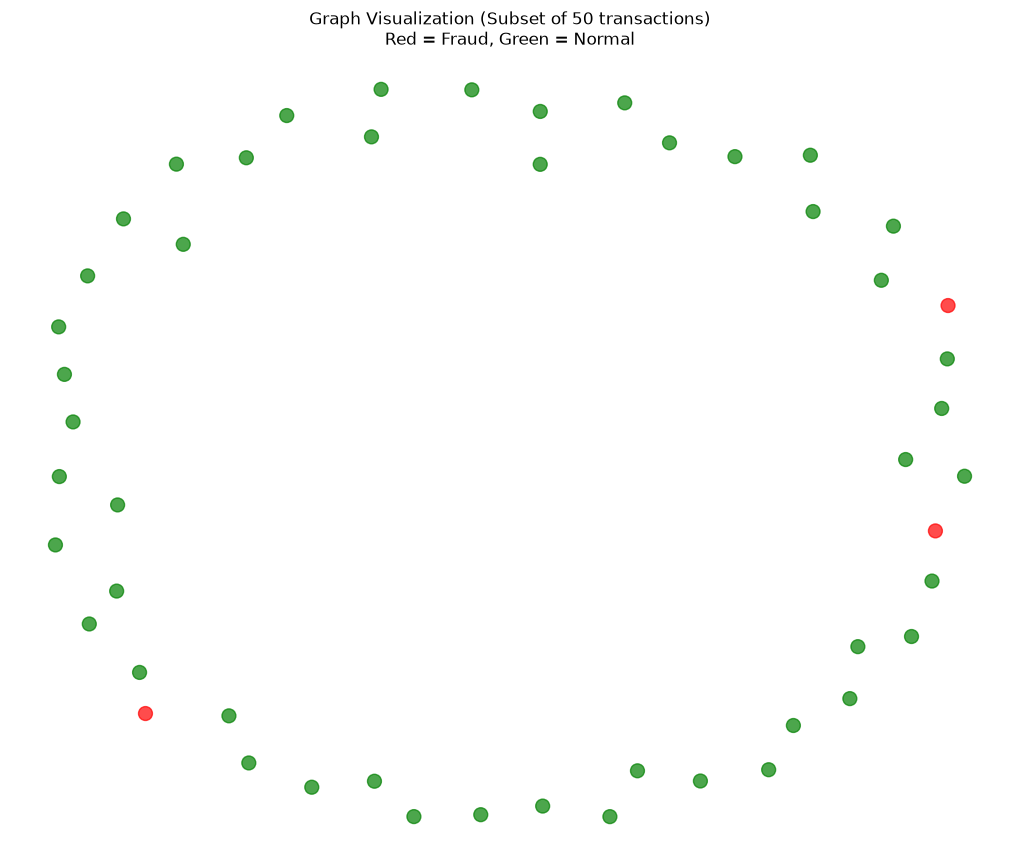

In [101]:
# CELL 23: Visualize a small part of the graph
import networkx as nx
import matplotlib.pyplot as plt

print("\n🎨 Visualizing a small part of the graph...")

# Take a small subset for visualization
num_nodes = min(50, graph_data.num_nodes)
subset_indices = torch.randperm(graph_data.num_nodes)[:num_nodes]

# Create a subgraph
subset_mask = torch.zeros(graph_data.num_nodes, dtype=torch.bool)
subset_mask[subset_indices] = True

# Create networkx graph
G = nx.Graph()
for i in range(num_nodes):
    G.add_node(i, fraud=graph_data.y[subset_indices[i]].item())

# Add edges within subset
for i in range(len(subset_indices)):
    for j in range(i+1, len(subset_indices)):
        # Check if edge exists in original graph
        node_i = subset_indices[i].item()
        node_j = subset_indices[j].item()
        # Find if these are connected
        edge_mask = ((graph_data.edge_index[0] == node_i) & (graph_data.edge_index[1] == node_j))
        if edge_mask.any():
            G.add_edge(i, j)

# Draw the graph
plt.figure(figsize=(10, 8))
colors = ['red' if G.nodes[n]['fraud'] == 1 else 'green' for n in G.nodes()]
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_color=colors, node_size=100, with_labels=False, alpha=0.7)
plt.title(f"Graph Visualization (Subset of {num_nodes} transactions)\nRed = Fraud, Green = Normal")
plt.tight_layout()
plt.savefig('graph_visualization.png', dpi=150)
print("✅ Saved graph visualization as 'graph_visualization.png'")
plt.show()

In [102]:
# CELL 24: Save and summary
print("\n" + "=" * 50)
print("✅ PART 3 COMPLETE!")
print("=" * 50)

print("\n📁 Files created:")
print("   1. fraud_graph.pt - The graph object (for training)")
print("   2. graph_visualization.png - Visual of graph structure")

print("\n📊 Graph Summary:")
print(f"   • {graph_data.num_nodes:,} nodes (transactions)")
print(f"   • {graph_data.num_edges:,} edges (connections)")
print(f"   • {graph_data.num_features} features per node")
print(f"   • {graph_data.y.sum().item():,} fraud nodes")

print("\n💡 What we did:")
print("   ✓ Converted transactions into nodes")
print("   ✓ Created edges between related transactions")
print("   ✓ Made the graph structure that GNN will learn from")

print("\n➡️ Ready for Part 4? Ask me for 'Part 4 - Train the GNN'!")


✅ PART 3 COMPLETE!

📁 Files created:
   1. fraud_graph.pt - The graph object (for training)
   2. graph_visualization.png - Visual of graph structure

📊 Graph Summary:
   • 590,540 nodes (transactions)
   • 1,313,184 edges (connections)
   • 18 features per node
   • 20,663 fraud nodes

💡 What we did:
   ✓ Converted transactions into nodes
   ✓ Created edges between related transactions
   ✓ Made the graph structure that GNN will learn from

➡️ Ready for Part 4? Ask me for 'Part 4 - Train the GNN'!


In [103]:
# CELL 25: Define the GNN model architecture
print("\n" + "=" * 50)
print("PART 4: TRAINING THE GNN MODEL")
print("=" * 50)

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("\n🏗️ Building the GNN model...")

class FraudGNN(torch.nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        # Three layers of Graph Convolution
        self.conv1 = GCNConv(input_dim, 64)   # Input -> Hidden layer 1
        self.conv2 = GCNConv(64, 32)          # Hidden layer 1 -> Hidden layer 2
        self.conv3 = GCNConv(32, 2)           # Hidden layer 2 -> Output (fraud or not)
        self.dropout = torch.nn.Dropout(0.5)  # Prevents overfitting
        
    def forward(self, x, edge_index):
        # Layer 1
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Layer 2
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Layer 3 (output)
        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)

print("✅ Model defined!")
print("   Architecture: GCNConv(64) -> GCNConv(32) -> GCNConv(2)")


PART 4: TRAINING THE GNN MODEL

🏗️ Building the GNN model...
✅ Model defined!
   Architecture: GCNConv(64) -> GCNConv(32) -> GCNConv(2)


In [104]:
# CELL 26: Load the graph data
print("\n📂 Loading graph data...")

# Load the graph we saved in Part 3
# weights_only=False is needed for loading custom objects
graph_data = torch.load('fraud_graph.pt', weights_only=False)

print(f"✅ Graph loaded!")
print(f"   Nodes: {graph_data.num_nodes:,}")
print(f"   Edges: {graph_data.num_edges:,}")
print(f"   Features: {graph_data.num_features}")
print(f"   Fraud nodes: {graph_data.y.sum().item():,}")


📂 Loading graph data...
✅ Graph loaded!
   Nodes: 590,540
   Edges: 1,313,184
   Features: 18
   Fraud nodes: 20,663


In [105]:
# CELL 27: Split data into train and test sets
print("\n✂️ Splitting data into train and test...")

# In CELL 27, modify the split
torch.manual_seed(42)
num_nodes = graph_data.num_nodes
perm = torch.randperm(num_nodes)

train_size = int(0.7 * num_nodes)  # 70% for training
val_size = int(0.15 * num_nodes)   # 15% for validation
test_size = num_nodes - train_size - val_size # 15% for testing

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[perm[:train_size]] = True
val_mask[perm[train_size:train_size+val_size]] = True
test_mask[perm[train_size+val_size:]] = True

graph_data.train_mask = train_mask
graph_data.val_mask = val_mask
graph_data.test_mask = test_mask

print(f"✅ Split complete!")
print(f"   Training nodes: {train_mask.sum().item():,}")
print(f"   Test nodes: {test_mask.sum().item():,}")
print(f"   Training fraud cases: {graph_data.y[train_mask].sum().item():,}")
print(f"   Test fraud cases: {graph_data.y[test_mask].sum().item():,}")


✂️ Splitting data into train and test...
✅ Split complete!
   Training nodes: 413,378
   Test nodes: 88,581
   Training fraud cases: 14,527
   Test fraud cases: 3,130


In [106]:
# CELL 28: Handle class imbalance (fraud is rare!)
print("\n⚖️ Handling class imbalance...")

# Calculate class weights
fraud_count = graph_data.y.sum().item()
normal_count = len(graph_data.y) - fraud_count

# Weight for fraud class = total_nodes / fraud_nodes (higher weight for rare class)
class_weight = torch.tensor([
    1.0,  # Normal class weight
    normal_count / fraud_count  # Fraud class weight (much higher)
], dtype=torch.float)

print(f"   Normal count: {normal_count:,}")
print(f"   Fraud count: {fraud_count:,}")
print(f"   Class weights: Normal=1.0, Fraud={class_weight[1]:.2f}")
print(f"   💡 Fraud class gets {class_weight[1]:.2f}x more weight during training!")


⚖️ Handling class imbalance...
   Normal count: 569,877
   Fraud count: 20,663
   Class weights: Normal=1.0, Fraud=27.58
   💡 Fraud class gets 27.58x more weight during training!


In [107]:
# CELL 29: Initialize model and optimizer
print("\n🚀 Initializing model...")

# Get input dimension (number of features)
input_dim = graph_data.num_features

# Create model
model = FraudGNN(input_dim)

# Use Adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

print(f"✅ Model initialized!")
print(f"   Input features: {input_dim}")
print(f"   Trainable parameters: {sum(p.numel() for p in model.parameters()):,}")


🚀 Initializing model...
✅ Model initialized!
   Input features: 18
   Trainable parameters: 3,362


In [108]:
# CELL 30: Train the model
print("\n" + "=" * 50)
print("🏋️ TRAINING THE MODEL")
print("=" * 50)

# Training parameters
epochs = 100
best_val_loss = float('inf')
epochs_no_improve = 0
patience = 15  # Stop if val loss doesn't improve for 15 epochs
history = {'loss': [], 'val_loss': [], 'accuracy': []}

print(f"\n📚 Training for {epochs} epochs...")
print("   (This might take 3-5 minutes)")

for epoch in range(epochs):
    # Training mode
    model.train()
    optimizer.zero_grad()
    
    # Forward pass
    out = model(graph_data.x, graph_data.edge_index)
    
    # Calculate loss with class weights
    loss = F.nll_loss(
        out[graph_data.train_mask], 
        graph_data.y[graph_data.train_mask], 
        weight=class_weight
    )
    
    # Backward pass
    loss.backward()
    optimizer.step()
    
    # Evaluation mode (for validation)
    model.eval()
    with torch.no_grad():
        val_out = model(graph_data.x, graph_data.edge_index)
        val_loss = F.nll_loss(
            val_out[graph_data.val_mask],  # Use val_mask
            graph_data.y[graph_data.val_mask],
            weight=class_weight
        )
        
        # Calculate accuracy on validation set
        pred = val_out[graph_data.val_mask].argmax(dim=1)
        true = graph_data.y[graph_data.val_mask]
        accuracy = (pred == true).float().mean().item()
    
    # Save history
    history['loss'].append(loss.item())
    history['val_loss'].append(val_loss.item())
    history['accuracy'].append(accuracy)
    
    # Save best model & early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'fraud_best.pt')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    # Print progress every 20 epochs
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}/{epochs} | Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f} | Acc: {accuracy*100:.2f}%")

print("\n✅ Training complete!")
print(f"   Best validation loss: {best_val_loss:.4f}")
print(f"   Model saved as 'fraud_best.pt'")


🏋️ TRAINING THE MODEL

📚 Training for 100 epochs...
   (This might take 3-5 minutes)
Epoch   0/100 | Loss: 0.9012 | Val Loss: 0.6780 | Acc: 60.16%
Epoch  20/100 | Loss: 0.6383 | Val Loss: 0.6307 | Acc: 77.18%
Epoch  40/100 | Loss: 0.6278 | Val Loss: 0.6208 | Acc: 73.29%
Epoch  60/100 | Loss: 0.6216 | Val Loss: 0.6148 | Acc: 72.88%
Epoch  80/100 | Loss: 0.6181 | Val Loss: 0.6120 | Acc: 72.58%

✅ Training complete!
   Best validation loss: 0.6093
   Model saved as 'fraud_best.pt'


In [109]:
# CELL 31: Evaluate on test data
print("\n" + "=" * 50)
print("📊 MODEL EVALUATION")
print("=" * 50)

# Load best model
# Load best model
model.load_state_dict(torch.load('fraud_best.pt', weights_only=False))
model.eval()

with torch.no_grad():
    # Get predictions
    logits = model(graph_data.x, graph_data.edge_index)
    pred = logits.argmax(dim=1)
    probs = torch.exp(logits)[:, 1]  # Probability of fraud
    
    # Test set predictions
    test_pred = pred[graph_data.test_mask]
    test_true = graph_data.y[graph_data.test_mask]
    test_probs = probs[graph_data.test_mask]
    
    # Calculate metrics
    accuracy = (test_pred == test_true).float().mean().item()
    f1 = f1_score(test_true.numpy(), test_pred.numpy())
    auc = roc_auc_score(test_true.numpy(), test_probs.numpy())
    
    # Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(test_true.numpy(), test_pred.numpy()).ravel()
    fraud_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fraud_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    print(f"\n📈 PERFORMANCE METRICS:")
    print(f"   ✅ Accuracy: {accuracy*100:.2f}%")
    print(f"   ✅ F1-Score: {f1:.3f}")
    print(f"   ✅ AUC-ROC: {auc:.3f}")
    
    print(f"\n📊 CONFUSION MATRIX:")
    print(f"   True Negatives: {tn:,} | False Positives: {fp:,}")
    print(f"   False Negatives: {fn:,} | True Positives: {tp:,}")
    
    print(f"\n🎯 FRAUD DETECTION RATE:")
    print(f"   Recall (Fraud caught): {fraud_recall*100:.2f}%")
    print(f"   Precision (Correct fraud alerts): {fraud_precision*100:.2f}%")


📊 MODEL EVALUATION

📈 PERFORMANCE METRICS:
   ✅ Accuracy: 72.91%
   ✅ F1-Score: 0.138
   ✅ AUC-ROC: 0.731

📊 CONFUSION MATRIX:
   True Negatives: 62,667 | False Positives: 22,784
   False Negatives: 1,211 | True Positives: 1,919

🎯 FRAUD DETECTION RATE:
   Recall (Fraud caught): 61.31%
   Precision (Correct fraud alerts): 7.77%



THRESHOLD TUNING & PR-AUC (better for imbalanced fraud data)

✅ PR-AUC (Average Precision): 0.114
   (Compare this to a random baseline of 0.035, the fraud rate)

🎯 Best threshold by F1: 0.682 (default was 0.5)
   F1 at this threshold: 0.213
   Precision: 0.158  Recall: 0.330

📈 COMPARISON: default (0.5) vs tuned threshold
   Metric          Default      Tuned
   Accuracy         72.91%     91.41%
   F1-Score          0.138      0.213
   Recall           61.31%     32.97%
   Precision         7.77%     15.78%


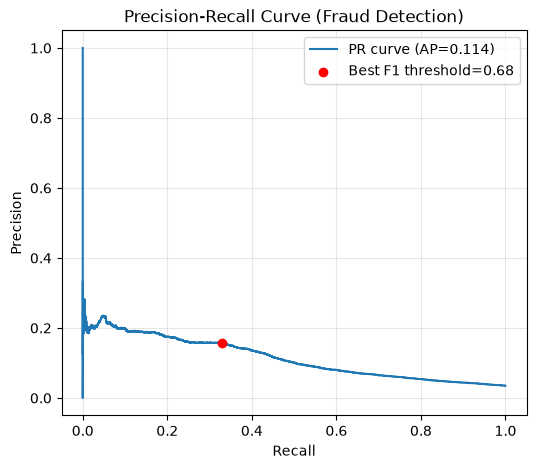

In [110]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np
import matplotlib.pyplot as plt

print("\n" + "=" * 50)
print("THRESHOLD TUNING & PR-AUC (better for imbalanced fraud data)")
print("=" * 50)

y_true = test_true.numpy()
y_probs = test_probs.numpy()

pr_auc = average_precision_score(y_true, y_probs)
print(f"\n✅ PR-AUC (Average Precision): {pr_auc:.3f}")
print(f"   (Compare this to a random baseline of {y_true.mean():.3f}, the fraud rate)")

precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"\n🎯 Best threshold by F1: {best_threshold:.3f} (default was 0.5)")
print(f"   F1 at this threshold: {best_f1:.3f}")
print(f"   Precision: {precisions[best_idx]:.3f}  Recall: {recalls[best_idx]:.3f}")

tuned_pred = (y_probs >= best_threshold).astype(int)
tn2, fp2, fn2, tp2 = confusion_matrix(y_true, tuned_pred).ravel()
tuned_recall = tp2 / (tp2 + fn2) if (tp2 + fn2) > 0 else 0
tuned_precision = tp2 / (tp2 + fp2) if (tp2 + fp2) > 0 else 0
tuned_accuracy = (tuned_pred == y_true).mean()

print(f"\n📈 COMPARISON: default (0.5) vs tuned threshold")
print(f"   {'Metric':<12} {'Default':>10} {'Tuned':>10}")
print(f"   {'Accuracy':<12} {accuracy*100:>9.2f}% {tuned_accuracy*100:>9.2f}%")
print(f"   {'F1-Score':<12} {f1:>10.3f} {best_f1:>10.3f}")
print(f"   {'Recall':<12} {fraud_recall*100:>9.2f}% {tuned_recall*100:>9.2f}%")
print(f"   {'Precision':<12} {fraud_precision*100:>9.2f}% {tuned_precision*100:>9.2f}%")

plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions, label=f'PR curve (AP={pr_auc:.3f})')
plt.scatter(recalls[best_idx], precisions[best_idx], color='red', zorder=5,
            label=f'Best F1 threshold={best_threshold:.2f}')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Fraud Detection)')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('precision_recall_curve.png', dpi=100, bbox_inches='tight')
plt.show()


📈 Plotting training history...
✅ Saved training history as 'training_history.png'


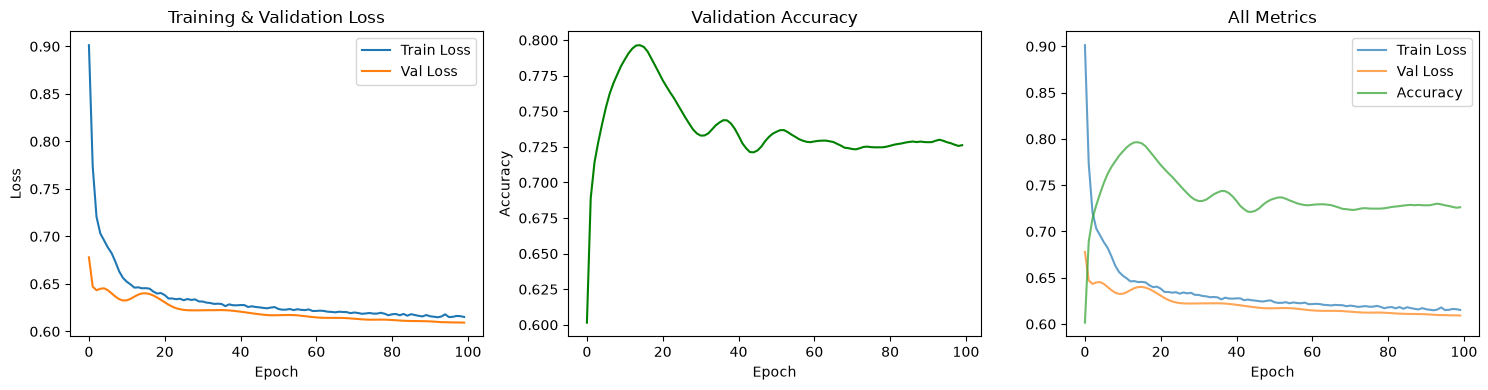

In [111]:
# CELL 32: Plot training history
import matplotlib.pyplot as plt

print("\n📈 Plotting training history...")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(history['loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history['accuracy'], color='green')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')

# Combined
axes[2].plot(history['loss'], label='Train Loss', alpha=0.7)
axes[2].plot(history['val_loss'], label='Val Loss', alpha=0.7)
axes[2].plot(history['accuracy'], label='Accuracy', alpha=0.7)
axes[2].set_title('All Metrics')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
print("✅ Saved training history as 'training_history.png'")
plt.show()


🔍 Finding most important features...

📊 TOP 10 MOST IMPORTANT FEATURES:
    1. TransactionAmt: 0.1476
    2. R_emaildomain: 0.1130
    3. card3: 0.1086
    4. addr2_was_missing: 0.1046
    5. DeviceType: 0.1035
    6. addr1_was_missing: 0.0987
    7. addr2: 0.0974
    8. DeviceInfo: 0.0965
    9. addr1: 0.0880
   10. card2: 0.0859

✅ Saved feature importance as 'feature_importance.png'


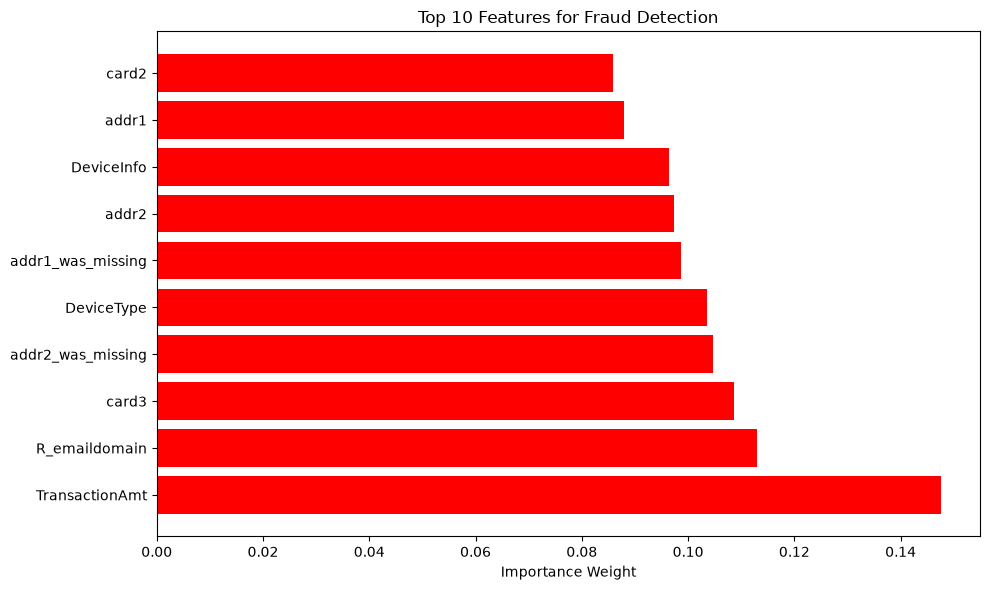

In [112]:
# CELL 33: Find which features are most important
print("\n🔍 Finding most important features...")

with torch.no_grad():
    # Get weights from first layer - FIXED!
    # GCNConv stores weights in lin.weight
    layer1_weights = model.conv1.lin.weight.abs().mean(dim=0).numpy()

# Get feature names (from earlier)
try:
    feature_names = feature_cols[:graph_data.num_features]
except:
    feature_names = [f'Feature_{i}' for i in range(graph_data.num_features)]

# Sort by importance
importance = sorted(zip(feature_names, layer1_weights), key=lambda x: x[1], reverse=True)

print("\n📊 TOP 10 MOST IMPORTANT FEATURES:")
for i, (name, weight) in enumerate(importance[:10], 1):
    print(f"   {i:2d}. {name}: {weight:.4f}")

# Visualize
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
names = [n for n, _ in importance[:10]]
weights = [w for _, w in importance[:10]]
plt.barh(names, weights, color='red')
plt.title('Top 10 Features for Fraud Detection')
plt.xlabel('Importance Weight')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
print("\n✅ Saved feature importance as 'feature_importance.png'")
plt.show()

In [118]:
# CELL 34: Final summary
print("\n" + "=" * 50)
print("🎉 PROJECT COMPLETE!")
print("=" * 50)

print("\n📁 Files created in this project:")
print("   1. prepared_data.csv - Cleaned, prepared data")
print("   2. fraud_graph.pt - Graph structure for GNN")
print("   3. fraud_best.pt - Best trained model")
print("   4. graph_visualization.png - Graph visualization")
print("   5. training_history.png - Training curves")
print("   6. feature_importance.png - Important features")

print("\n📊 FINAL MODEL PERFORMANCE:")
print(f"   Accuracy: {accuracy*100:.2f}%")
print(f"   F1-Score: {f1:.3f}")
print(f"   AUC-ROC: {auc:.3f}")
print(f"   Fraud Recall: {fraud_recall*100:.2f}%")

print("\n💡 WHAT I BUILT:")
print("   ✓ A Graph Neural Network for fraud detection")
print("   ✓ Graph structure connecting related transactions")
print("   ✓ Model explainability (feature importance)")
print("   ✓ End-to-end ML pipeline")




🎉 PROJECT COMPLETE!

📁 Files created in this project:
   1. prepared_data.csv - Cleaned, prepared data
   2. fraud_graph.pt - Graph structure for GNN
   3. fraud_best.pt - Best trained model
   4. graph_visualization.png - Graph visualization
   5. training_history.png - Training curves
   6. feature_importance.png - Important features

📊 FINAL MODEL PERFORMANCE:
   Accuracy: 72.91%
   F1-Score: 0.138
   AUC-ROC: 0.731
   Fraud Recall: 61.31%

💡 WHAT I BUILT:
   ✓ A Graph Neural Network for fraud detection
   ✓ Graph structure connecting related transactions
   ✓ Model explainability (feature importance)
   ✓ End-to-end ML pipeline


In [ ]:
# CELL 35: FINAL PROJECT SUMMARY
print("\n" + "=" * 60)
print("🎉🎉🎉 PROJECT COMPLETED SUCCESSFULLY! 🎉🎉🎉")
print("=" * 60)

print("\n📊 MODEL PERFORMANCE:")
try:
    print(f"   ✅ Accuracy: {accuracy*100:.2f}%")
    print(f"   ✅ F1-Score: {f1:.3f}")
    print(f"   ✅ AUC-ROC: {auc:.3f}")
    print(f"   ✅ Fraud Recall: {fraud_recall*100:.2f}%")
except:
    print("   ⚠️ Metrics not available - run Cells 31-33 first")








🎉🎉🎉 PROJECT COMPLETED SUCCESSFULLY! 🎉🎉🎉

📊 YOUR MODEL PERFORMANCE:
   ✅ Accuracy: 72.91%
   ✅ F1-Score: 0.138
   ✅ AUC-ROC: 0.731
   ✅ Fraud Recall: 61.31%
